# Silver Analytics - Amazon Products

Analise de qualidade dos dados limpos da camada Silver.

**Fonte de dados:** PostgreSQL (tabela `silver.product`)

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import warnings

warnings.filterwarnings('ignore', category=UserWarning, message='.*SQLAlchemy.*')

## 1. Carregamento

In [126]:
plt.style.use('seaborn-v0_8')
sns.set_theme(context="notebook", style="whitegrid")

# Configuração do banco de dados
DB_CONFIG = {
    'host': 'localhost',
    'port': 5432,
    'database': 'amazon_sales',
    'user': 'postgres',
    'password': 'postgres'
}

# Conectar ao PostgreSQL
conn = psycopg2.connect(**DB_CONFIG)

# Carregar dados da camada Silver
df_silver = pd.read_sql_query("""
    SELECT 
        asin, title, brand, category,
        rating, total_reviews as review_count, quality_score,
        discounted_price as final_price, original_price,
        price_range as price_tier, discount_percentage as discount_pct,
        is_best_seller as best_seller_badge,
        is_sponsored as sponsored_badge,
        has_coupon as has_active_coupon,
        buy_box_availability as available_for_purchase,
        purchased_last_month as units_sold_last_month,
        date
    FROM silver.product
""", conn)

# Ajustar tipos essenciais
df_silver['brand'] = df_silver['brand'].fillna('unknown')
df_silver['category'] = df_silver['category'].fillna('Other')
df_silver['date'] = pd.to_datetime(df_silver['date'])
df_silver['day_name'] = df_silver['date'].dt.day_name()
df_silver['is_discounted'] = df_silver['discount_pct'] > 0
df_silver['is_promotable'] = (df_silver['rating'] >= 4.0) & (df_silver['review_count'] >= 100)
df_silver['price_source'] = 'database'

print(f"✓ {len(df_silver):,} registros carregados do PostgreSQL")

✓ 15,938 registros carregados do PostgreSQL


In [127]:
missing_data = pd.DataFrame({
    'Coluna': df_silver.columns,
    'Nulos': df_silver.isnull().sum().values,
    'Total': df_silver.isnull().sum().values,
    '%': (df_silver.isnull().sum().values / len(df_silver) * 100).round(2)
})

missing_data = missing_data[missing_data['Total'] > 0].sort_values('Total', ascending=False)

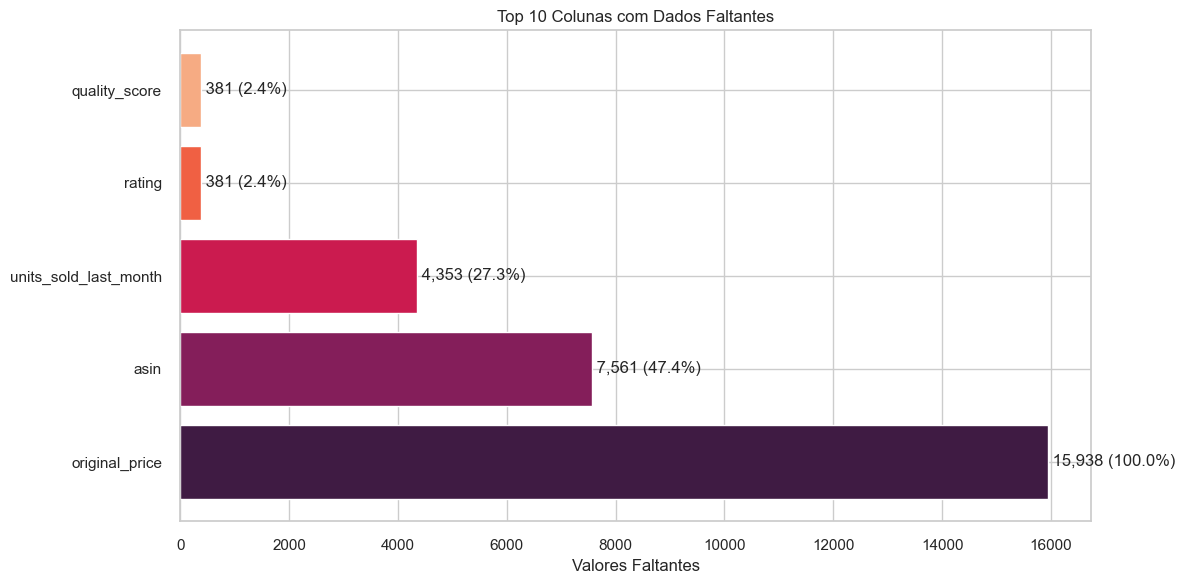

In [128]:
if len(missing_data) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    top_missing = missing_data.head(10)
    colors = sns.color_palette('rocket', n_colors=len(top_missing))
    
    ax.barh(top_missing['Coluna'], top_missing['Total'], color=colors)
    ax.set_xlabel('Valores Faltantes')
    ax.set_title('Top 10 Colunas com Dados Faltantes')
    
    for i, (idx, row) in enumerate(top_missing.iterrows()):
        ax.text(row['Total'], i, f" {row['Total']:,.0f} ({row['%']:.1f}%)", ha='left', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum valor faltante significativo na camada Silver")

## 4. Distribuicao por Categoria

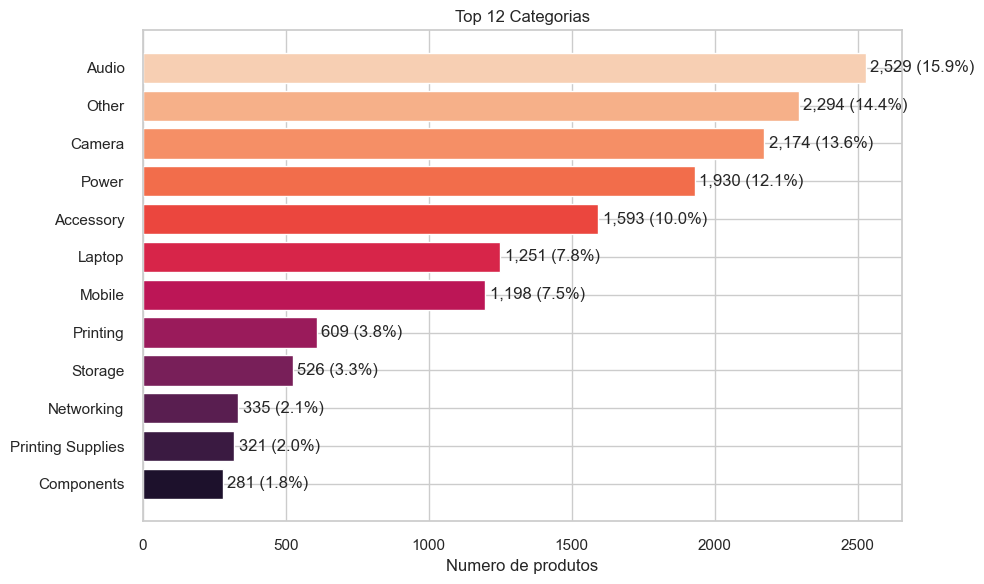

In [129]:
top_categories = df_silver['category'].value_counts().head(12).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('rocket', n_colors=len(top_categories))
ax.barh(top_categories.index, top_categories.values, color=colors)
ax.set_title('Top 12 Categorias')
ax.set_xlabel('Numero de produtos')

for i, v in enumerate(top_categories.values):
    pct = v / len(df_silver) * 100
    ax.text(v + 15, i, f"{v:,} ({pct:.1f}%)", va='center')

plt.tight_layout()
plt.show()

## 5. Faixas de Preco e Fonte

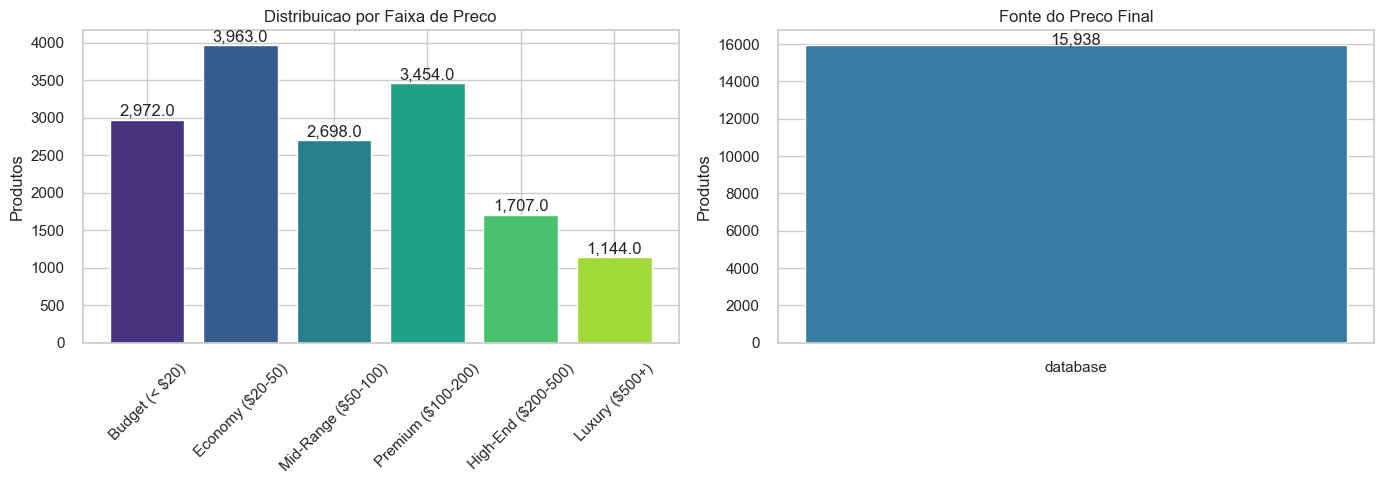

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_tiers = df_silver['price_tier'].value_counts().reindex([
    'Budget (< $20)', 'Economy ($20-50)', 'Mid-Range ($50-100)',
    'Premium ($100-200)', 'High-End ($200-500)', 'Luxury ($500+)', 'Unknown'
]).dropna()

axes[0].bar(price_tiers.index, price_tiers.values, color=sns.color_palette('viridis', len(price_tiers)))
axes[0].set_title('Distribuicao por Faixa de Preco')
axes[0].set_ylabel('Produtos')
axes[0].tick_params(axis='x', rotation=45)
for x, y in enumerate(price_tiers.values):
    axes[0].text(x, y + 50, f"{y:,}", ha='center')

price_sources = df_silver['price_source'].value_counts()
axes[1].bar(price_sources.index, price_sources.values, color=sns.color_palette('mako', len(price_sources)))
axes[1].set_title('Fonte do Preco Final')
axes[1].set_ylabel('Produtos')
for x, y in enumerate(price_sources.values):
    axes[1].text(x, y + 50, f"{y:,}", ha='center')

plt.tight_layout()
plt.show()

## 7. Distribuicao de Ratings e Dispersao

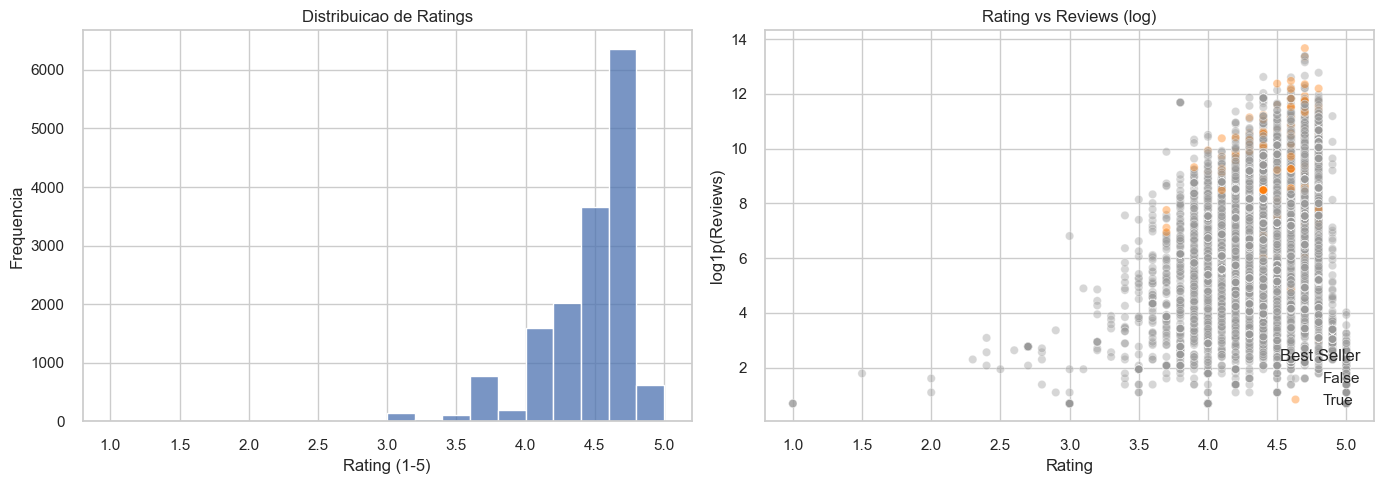

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_silver['rating'].dropna(), bins=20, ax=axes[0], color="#4c72b0")
axes[0].set_title('Distribuicao de Ratings')
axes[0].set_xlabel('Rating (1-5)')
axes[0].set_ylabel('Frequencia')

sns.scatterplot(
    data=df_silver,
    x='rating',
    y=np.log1p(df_silver['review_count']),
    hue='best_seller_badge',
    palette=['#999999', '#ff7f0e'],
    alpha=0.4,
    ax=axes[1]
)
axes[1].set_title('Rating vs Reviews (log)')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('log1p(Reviews)')
axes[1].legend(title='Best Seller', loc='lower right')

plt.tight_layout()
plt.show()

## 10. Distribuicao de Completude por Coluna

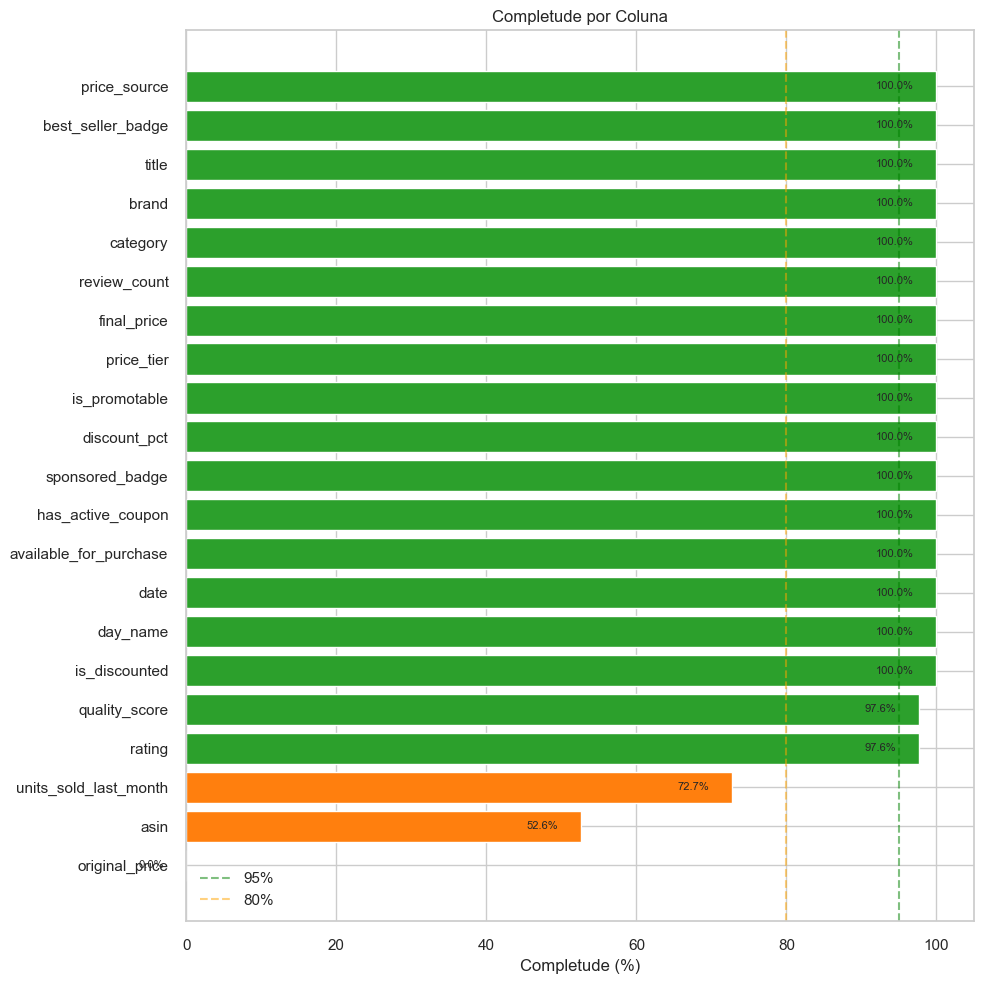

✓ Conexão com o banco de dados encerrada


In [132]:
completeness_by_col = ((df_silver.notna().sum() / len(df_silver)) * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors_gradient = ['#d62728' if x < 50 else '#ff7f0e' if x < 80 else '#2ca02c' for x in completeness_by_col]
ax.barh(completeness_by_col.index, completeness_by_col.values, color=colors_gradient)
ax.set_xlabel('Completude (%)')
ax.set_title('Completude por Coluna')
ax.axvline(95, color='green', linestyle='--', alpha=0.5, label='95%')
ax.axvline(80, color='orange', linestyle='--', alpha=0.5, label='80%')

for i, v in enumerate(completeness_by_col.values):
    ax.text(v - 3, i, f"{v:.1f}%", va='center', ha='right', fontsize=8)

ax.legend()
plt.tight_layout()
plt.show()

conn.close()
print("✓ Conexão com o banco de dados encerrada")
